In [1]:
# illustrative example of use GEMS 

## Creating a Local Butler for a Selected Set of Visits

> Version: 1.0
> Container Size: Large

> Description: In this notebook, we present illustrative examples of using Vera Rubin’s functions to create a local Butler for a chosen set of visits.

In [1]:
# Complementary info
! echo $IMAGE_DESCRIPTION
! eups list -s | grep lsst_distrib

!python --version

Release r30.0.11 (RSP Build 3040)
lsst_distrib          gdfb3db0272+232e9e9820 	v30_0_11 current v30_0_11_rc1 o_latest setup
Python 3.13.9


In [2]:
%load_ext autoreload
%autoreload

In [1]:
import numpy as np
import gems
import matplotlib.pyplot as plt

from lsst.daf.butler import Butler
from astropy.io import fits

### Loading the butler and show some information

In [2]:
# Initialize Butler
COLLECTION = "LSSTComCam/DP1"
REPOSITORY = "dp1"

butler = Butler(config=REPOSITORY, collections=COLLECTION)
assert butler is not None

In [3]:
import lsst.sphgeom as sphgeom

## Identify visit images around location

In [4]:
# Identify visit images around location
ra_deg, dec_deg = (59.6214272, -49.0586792)
loc_data = ra_deg, dec_deg

bands = ['i', 'r', 'g']

visit_name = "visit_image"
print(f"Using -> {visit_name}")

visits_image_selected_list = {}
for band in bands:
    visit_refs = gems.visit_dataset(butler, band, (2394, 3), type_loc_data='patch_area', detectors=None, timespan=None, visit_ids=None)
    print(f'[INF] Found {len(visit_refs)} visits in band {band}')
    visits_image_selected_list[band] = visit_refs  # Saving the visit data set per band

Using -> visit_image
[INF] Found 41 visits in band i
[INF] Found 83 visits in band r
[INF] Found 65 visits in band g


## Creating the local butler repository and copying the visits

In [5]:
# General CONFIGURATION
LOCAL_REPO = os.path.expandvars("$SCRATCH_DIR/local_butler_coadd_valid")   # Local butler repo path (relative to this notebook, inside examples/)
REMOTE_REPO = gems.get_butler_location(butler)  # Remote butler repo path
COLLECTION = "LSSTComCam/DP1"

In [6]:
visits_i = visits_image_selected_list['i']

In [60]:
def make_butler(LOCAL_REPO, REMOTE_REPO, COLLECTION, data_visits):
    # Make the object/Setup logging directory and logger
    lbutler = gems.LocalButler(local_repo=LOCAL_REPO, remote_repo=REMOTE_REPO, LOGDIR=LOCAL_REPO+"/logs")

    # Creating an empty butler
    lbutler.make_repo()

    # Register instruments (collect unique instrument names from DatasetRefs)
    lbutler.reg_instruments(visits_i, remote_collection=COLLECTION)

    # Registering SkyMap DatasetType and copying skyMap dataset(s) (preserving UUIDs)
    lbutler.reg_transfer_skyMap(remote_collection=COLLECTION)

    # transfer some datasets associated to "visit_image"
    for visits in data_visits:
        lbutler.discover_transfer_datasets(visits, remote_collection=COLLECTION)

    # Finally, create a chained collection
    lbutler.chained(chain_name="local_main_chain")

    return True

In [61]:
# Making the local butler
data_visits = [visits_i]

make_butler(LOCAL_REPO, REMOTE_REPO, COLLECTION, data_visits)

2026-09-14 15:42:01 [INFO] Created LOGDIR at /deleted-sundays/jhuda/local_butler_coadd_valid/deleted-sundays/jhuda/local_butler_coadd_valid/logs


2026-09-14 15:42:01 [INFO] Starting pipeline for local repo: /deleted-sundays/jhuda/local_butler_coadd_valid


2026-09-14 15:42:01 [INFO] Creating Butler repo at /deleted-sundays/jhuda/local_butler_coadd_valid


2026-09-14 15:42:01 [INFO] Registering instruments: ['LSSTComCam']


2026-09-14 15:42:01 [INFO] Detected instruments to register: ['LSSTComCam']


...

2026-09-14 15:54:23 [INFO] Making a chained collection


2026-09-14 15:54:24 [INFO] Creating chained collection 'local_main_chain' with members: ['skymaps', 'skymaps', 'LSSTComCam/runs/DRP/DP1/DM-51335', 'LSSTComCam/runs/DRP/DP1/DM-53601', 'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z']


2026-09-14 15:54:24 [INFO] Registered CHAINED collection: local_main_chain


2026-09-14 15:54:24 [INFO] Set chain for 'local_main_chain' -> ['skymaps', 'skymaps', 'LSSTComCam/runs/DRP/DP1/DM-51335', 'LSSTComCam/runs/DRP/DP1/DM-53601', 'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z']


True

## Visualizing some local butler's information

In [20]:
print("List of avalibles colections:")
# Collections
!butler query-collections --chains 'TREE' $LOCAL_REPO

List of avalibles colections:
                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
custom_coadd_full                                           CHAINED
  custom_coadd_full/20260914T163246Z                        RUN    
  custom_coadd_full/inputs                                  TAGGED 
custom_coadd_full/20260914T163246Z                          RUN    
custom_coadd_full/inputs                                    TAGGED 
deep_coadd_recreation                                       CHAINED
  deep_coadd_recreation/20260914T190316Z                    RUN    
  deep_coadd_recreation/inputs                              TAGGED 
deep_coadd_recreation/20260914T190316Z                      RUN    
deep_coadd_recreat

In [8]:
# Dataset types
print("List of avalibles datasetType:")
!butler query-dataset-types --verbose $LOCAL_REPO

List of avalibles datasetType:
             name                                                      dimensions                                          storage class   
------------------------------ ----------------------------------------------------------------------------------------- ------------------
assembleDeepCoadd_config       []                                                                                        Config            
assembleDeepCoadd_log          ['band', 'skymap', 'tract', 'patch']                                                      ButlerLogRecords  
assembleDeepCoadd_metadata     ['band', 'skymap', 'tract', 'patch']                                                      TaskMetadata      
compare_warp_artifact_mask     ['band', 'instrument', 'skymap', 'day_obs', 'physical_filter', 'tract', 'patch', 'visit'] Mask              
deep_coadd                     ['band', 'skymap', 'tract', 'patch']                                                      Exposure

In [9]:
# Skymap collection
print("List of avalibles Skymaps:")
!butler query-datasets $LOCAL_REPO skyMap --collections skymaps

List of avalibles Skymaps:

 type    run                    id                      skymap   
------ ------- ------------------------------------ -------------
skyMap skymaps 64c16b0a-0a1a-4f78-81e5-f49a9328c388 lsst_cells_v1



In [10]:
# identifying the RUN name of visit_summary
!butler query-datasets $LOCAL_REPO visit_summary \
  --collections local_main_chain \
  --limit 60


     type                                run                                             id                  instrument     visit     band day_obs  physical_filter
------------- --------------------------------------------------------- ------------------------------------ ---------- ------------- ---- -------- ---------------
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z 80af2c9b-616b-496e-a181-198cdeeb79c0 LSSTComCam 2024111700345    i 20241117            i_06
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z 93b2b6fb-7b7e-4c3b-877e-53c5668e6308 LSSTComCam 2024111700348    i 20241117            i_06
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z 6a2a26f4-80f9-4021-9b71-708a8521251f LSSTComCam 2024111700349    i 20241117            i_06
visit_summary LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z 4db3bc52-e2df-4467-ab14-1f66b85525b0 LSSTComCam 2024111700360    i 20241117            i_06
visit_summary L

## Deep Coadd recreation

In this example, we perform a validation of the coadd making process, we redo a deep_coadd using GEMS and show how close it gets to the actual deep coadd in rubin. 

In [12]:
lbutler = Butler(LOCAL_REPO, collections="local_main_chain")
deep_coadd = lbutler.get('deep_coadd', dataId={'band': 'i', 'skymap': 'lsst_cells_v1', 'tract': 2394, 'patch': 3})
info_dc = deep_coadd.getInfo()
inputs_dc = info_dc.getCoaddInputs()
inputs = inputs_dc.visits.asAstropy()

In [13]:
inputs

id,bbox_min_x,bbox_min_y,bbox_max_x,bbox_max_y,goodpix,weight,filter
,pix,pix,pix,pix,,,
int64,int32,int32,int32,int32,int32,float64,str32
2024111700345,8544,-456,12455,3455,1315761,0.0008240437947005582,i_06
2024111700348,8544,-456,12455,3455,2861887,0.0007979855514706616,i_06
2024111700349,8544,-456,12455,3455,5763028,0.0008006550666899183,i_06
2024111700360,8544,-456,12455,3455,1293335,0.0007985024482641637,i_06
2024111700362,8544,-456,12455,3455,387785,0.0008299154155645411,i_06
2024111700363,8544,-456,12455,3455,7339722,0.0008201286243347281,i_06
2024111800088,8544,-456,12455,3455,1383555,0.0015079465664190285,i_06
2024111800090,8544,-456,12455,3455,5686214,0.0015368412212227107,i_06


### Making a deep coadd

In [14]:
import pandas as pd

In [16]:
inj_lbutler = Butler(LOCAL_REPO, collections="local_main_chain")
refs = inj_lbutler.query_datasets("visit_image")

visits_selected = {'visit_id': [], 'band': []}
for ref in inputs:
    visits_selected['visit_id'].append(ref['id'])
    visits_selected['band'].append('i')

pd_visits_selected = pd.DataFrame(visits_selected)

In [17]:
pd_visits_selected

,visit_id,band
0,2024111700345,i
1,2024111700348,i
2,2024111700349,i
3,2024111700360,i
4,2024111700362,i
5,2024111700363,i
6,2024111800088,i
7,2024111800090,i
8,2024111800091,i
9,2024111800092,i


In [18]:
# Identify visit images around location
loc_data = ra_deg, dec_deg

In [19]:
gems.custom_coadd_multiband(BUTLER_PATH=LOCAL_REPO,
                          BUTLER_SAVE_PATH=LOCAL_REPO,
                          loc_data=loc_data,
                          visits_selected=pd_visits_selected,
                          bands=None,
                          skymap_name='lsst_cells_v1',
                          remote_collection='local_main_chain',
                          my_collection_name='deep_coadd_recreation',
                          type_loc_data='sky_coordinates',
                          SAVE_FITS=False,
                          out=False)

/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_algorithms/gab846f1091+7d60317af5/python/lsst/meas/algorithms/maskStreaks.py:256: RuntimeWarning: invalid value encountered in divide
  detectionFraction = detectionsAlongStreak / countAlongStreak
/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_algorithms/gab846f1091+7d60317af5/python/lsst/meas/algorithms/maskStreaks.py:426: RuntimeWarning: invalid value encountered in divide
  rChi2AlongStreak = chi2AlongStreak / countAlongStreak


[INFO] Metadata saved: /deleted-sundays/jhuda/local_butler_coadd_valid/custom_coadd_info.txt


In [21]:
# some checks
!butler query-collections --chains 'TREE' $LOCAL_REPO

                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
custom_coadd_full                                           CHAINED
  custom_coadd_full/20260914T163246Z                        RUN    
  custom_coadd_full/inputs                                  TAGGED 
custom_coadd_full/20260914T163246Z                          RUN    
custom_coadd_full/inputs                                    TAGGED 
deep_coadd_recreation                                       CHAINED
  deep_coadd_recreation/20260914T190316Z                    RUN    
  deep_coadd_recreation/inputs                              TAGGED 
deep_coadd_recreation/20260914T190316Z                      RUN    
deep_coadd_recreation/inputs                    

In [23]:
!butler query-dataset-types $LOCAL_REPO --collections deep_coadd_recreation

             name             
------------------------------
assembleDeepCoadd_config      
assembleDeepCoadd_log         
assembleDeepCoadd_metadata    
compare_warp_artifact_mask    
deep_coadd_input_map          
deep_coadd_n_image            
deep_coadd_predetection       
deep_coadd_visit_selection    
direct_warp                   
direct_warp_masked_fraction   
makeDirectWarp_config         
makeDirectWarp_log            
makeDirectWarp_metadata       
makePsfMatchedWarp_config     
makePsfMatchedWarp_log        
makePsfMatchedWarp_metadata   
packages                      
psf_matched_warp              
selectDeepCoaddVisits_config  
selectDeepCoaddVisits_log     
selectDeepCoaddVisits_metadata
skyMap                        
visit_image                   
visit_summary                 


In [25]:
!butler query-datasets $LOCAL_REPO deep_coadd_visit_selection \
  --collections deep_coadd_recreation \
  --limit 5


           type                             run                                    id                  band instrument     skymap    tract patch
-------------------------- -------------------------------------- ------------------------------------ ---- ---------- ------------- ----- -----
deep_coadd_visit_selection deep_coadd_recreation/20260914T190316Z 01a0a14d-5b57-7471-97b7-33356397f2c5    i LSSTComCam lsst_cells_v1  2394     3



### Comparing with the full deep_coadd

In [26]:
import os
import json

In [27]:
local_repo_path = LOCAL_REPO #os.path.join(os.getenv("HOME"), LOCAL_REPO) 
info_txt_path = os.path.join(local_repo_path, "custom_coadd_info.txt")

with open(info_txt_path, "r") as f:
        info = json.load(f)

info

{'repo_path': '/deleted-sundays/jhuda/local_butler_coadd_valid',
 'collection': 'deep_coadd_recreation/20260914T190316Z',
 'coadd_type': 'deep_coadd_predetection',
 'tract': 2394,
 'patch': '3',
 'bands': ['i'],
 'instrument': 'LSSTComCam',
 'skymap': 'lsst_cells_v1'}

In [30]:
lbutler = Butler(LOCAL_REPO, collections="local_main_chain")

inj_coadd_lbutler = Butler(LOCAL_REPO, collections='deep_coadd_recreation') 

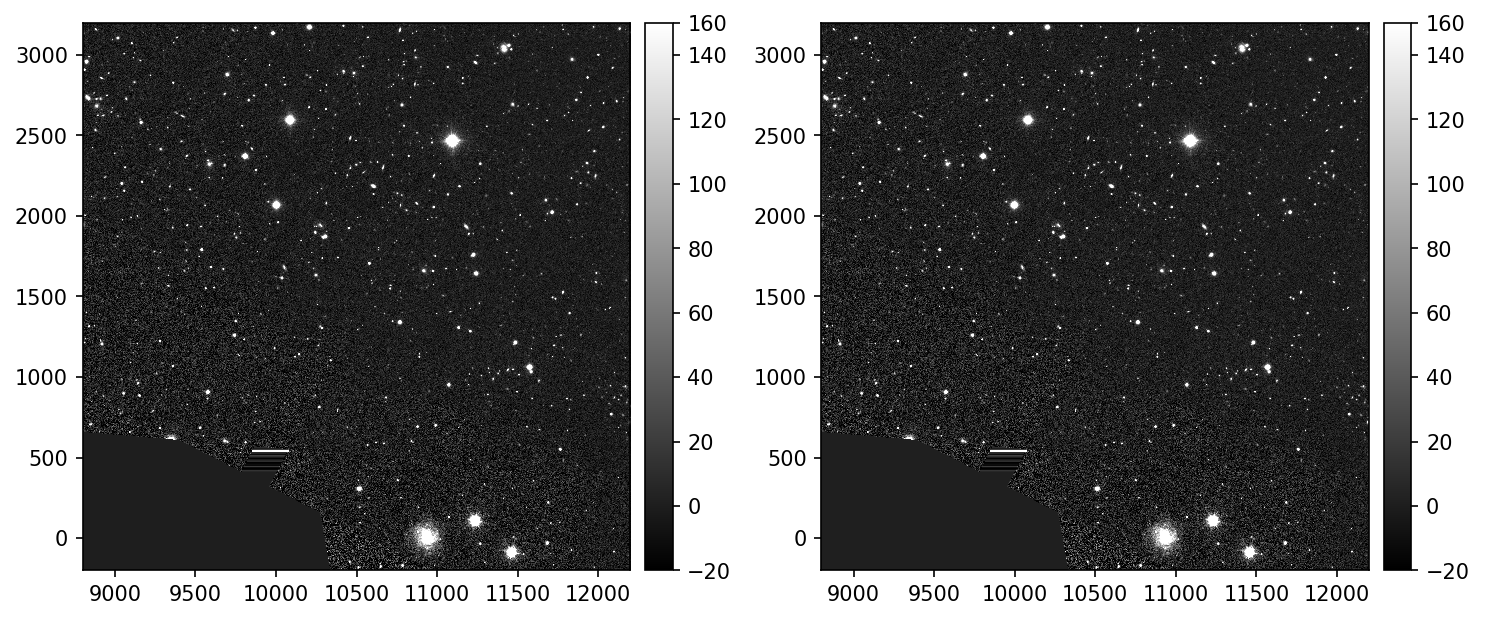

In [31]:
import lsst.afw.display as afwDisplay
afwDisplay.setDefaultBackend("matplotlib")


coadd = lbutler.get('deep_coadd', dataId={'band': 'i', 'skymap': 'lsst_cells_v1', 'tract': 2394, 'patch': 3})
inj_coadd = inj_coadd_lbutler.get('deep_coadd_predetection', dataId={'band': 'i', 'skymap': 'lsst_cells_v1', 'tract': 2394, 'patch': 3})

fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=150)

plt.sca(ax[0])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(inj_coadd.image)


plt.sca(ax[1])
display0 = afwDisplay.Display(frame=fig)
# display0.scale('linear', 'zscale')
display0.scale('linear', min=-20, max=150)
display0.mtv(coadd.image)

plt.tight_layout()

[INFO] Converted LSST SkyWcs -> Astropy WCS


/home/jhuda/.local/lib/python3.13/site-packages/gems/utils/plot/exposure_plot.py:200: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.


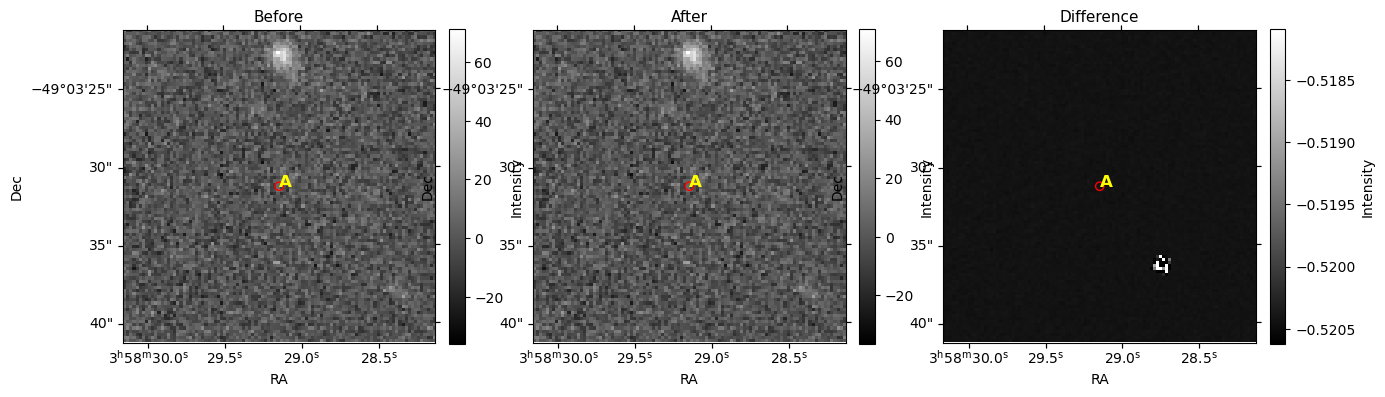

In [32]:
# Simple comparison (subtraction of both)
points = [loc_data]
before = coadd
after = inj_coadd

# necessary because the corner no is (0, 0)
bbox = after.getBBox()
xmin = bbox.getMinX()
xmax = bbox.getMaxX()
ymin = bbox.getMinY()
ymax = bbox.getMaxY()

gems.injection_steps(before,
                   after,
                   points,
                   diference=True,
                   cutout_radius_arcsec=10,  # arcsec  10
                   grid=False, percentiles=[1, 99],
                   extent=[xmin, xmax, ymin, ymax])

[INFO] Converted LSST SkyWcs -> Astropy WCS
===> Cleaning masks
===> Run detection


===> Run Deblend and Measurement


Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/sourceDeblendTask.py", line 390, in deblend
    res = deblend(
        fp, mi, psf, psf_fwhm, sigma1=sigma1,
    ...<14 lines>...
        medianSmoothTemplate=self.config.medianSmoothTemplate
    )
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 676, in deblend
    debResult = newDeblend(debPlugins, footprint, maskedImage, psf, psffwhm, log, verbose, avgNoise)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 748, in newDeblend
    reset = debPlugins[step].run(debResult, log)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/L

Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/sourceDeblendTask.py", line 390, in deblend
    res = deblend(
        fp, mi, psf, psf_fwhm, sigma1=sigma1,
    ...<14 lines>...
        medianSmoothTemplate=self.config.medianSmoothTemplate
    )
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 676, in deblend
    debResult = newDeblend(debPlugins, footprint, maskedImage, psf, psffwhm, log, verbose, avgNoise)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 748, in newDeblend
    reset = debPlugins[step].run(debResult, log)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/L

Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/sourceDeblendTask.py", line 390, in deblend
    res = deblend(
        fp, mi, psf, psf_fwhm, sigma1=sigma1,
    ...<14 lines>...
        medianSmoothTemplate=self.config.medianSmoothTemplate
    )
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 676, in deblend
    debResult = newDeblend(debPlugins, footprint, maskedImage, psf, psffwhm, log, verbose, avgNoise)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 748, in newDeblend
    reset = debPlugins[step].run(debResult, log)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/L

...

Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/sourceDeblendTask.py", line 390, in deblend
    res = deblend(
        fp, mi, psf, psf_fwhm, sigma1=sigma1,
    ...<14 lines>...
        medianSmoothTemplate=self.config.medianSmoothTemplate
    )
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 676, in deblend
    debResult = newDeblend(debPlugins, footprint, maskedImage, psf, psffwhm, log, verbose, avgNoise)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 748, in newDeblend
    reset = debPlugins[step].run(debResult, log)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/L

Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/sourceDeblendTask.py", line 390, in deblend
    res = deblend(
        fp, mi, psf, psf_fwhm, sigma1=sigma1,
    ...<14 lines>...
        medianSmoothTemplate=self.config.medianSmoothTemplate
    )
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 676, in deblend
    debResult = newDeblend(debPlugins, footprint, maskedImage, psf, psffwhm, log, verbose, avgNoise)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 748, in newDeblend
    reset = debPlugins[step].run(debResult, log)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/L

Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/sourceDeblendTask.py", line 390, in deblend
    res = deblend(
        fp, mi, psf, psf_fwhm, sigma1=sigma1,
    ...<14 lines>...
        medianSmoothTemplate=self.config.medianSmoothTemplate
    )
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 676, in deblend
    debResult = newDeblend(debPlugins, footprint, maskedImage, psf, psffwhm, log, verbose, avgNoise)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 748, in newDeblend
    reset = debPlugins[step].run(debResult, log)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/L

===> Selecting sky sources
Sky sources seleccionadas: 1663
===> Warping
===> Subtracting


/home/jhuda/.local/lib/python3.13/site-packages/gems/utils/plot/exposure_plot.py:200: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.


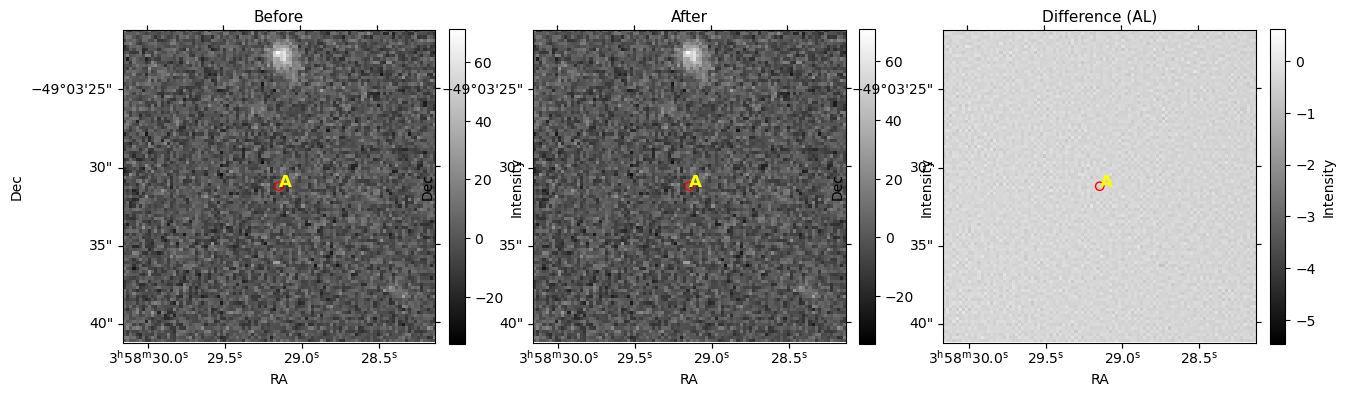

In [33]:
gems.injection_steps_AlardLupton(before,
                   after,
                   points,
                   diference=True,
                   cutout_radius_arcsec=10,  # arcsec  10
                   grid=False, percentiles=[1, 99],
                   extent=[xmin, xmax, ymin, ymax])

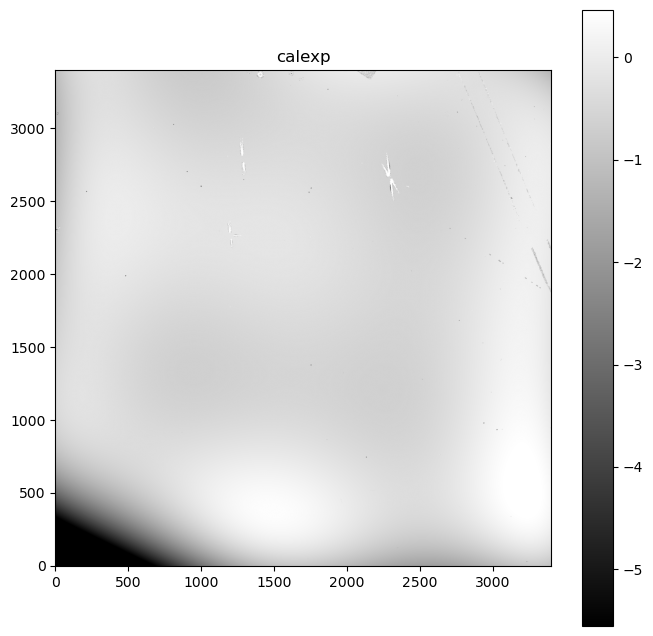

In [34]:
diff = inj_coadd.clone()
diff.image.array[:] = inj_coadd.image.array - coadd.image.array

plt.figure(figsize=(8,8))
plt.imshow(diff.image.array, origin="lower", cmap="gray",
           vmin=np.percentile(diff.image.array, 1),
           vmax=np.percentile(diff.image.array, 99))
plt.colorbar()
plt.title("calexp")
plt.show()

===> Cleaning masks
===> Run detection


===> Run Deblend and Measurement


Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/sourceDeblendTask.py", line 390, in deblend
    res = deblend(
        fp, mi, psf, psf_fwhm, sigma1=sigma1,
    ...<14 lines>...
        medianSmoothTemplate=self.config.medianSmoothTemplate
    )
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 676, in deblend
    debResult = newDeblend(debPlugins, footprint, maskedImage, psf, psffwhm, log, verbose, avgNoise)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 748, in newDeblend
    reset = debPlugins[step].run(debResult, log)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/L

Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/sourceDeblendTask.py", line 390, in deblend
    res = deblend(
        fp, mi, psf, psf_fwhm, sigma1=sigma1,
    ...<14 lines>...
        medianSmoothTemplate=self.config.medianSmoothTemplate
    )
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 676, in deblend
    debResult = newDeblend(debPlugins, footprint, maskedImage, psf, psffwhm, log, verbose, avgNoise)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 748, in newDeblend
    reset = debPlugins[step].run(debResult, log)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/L

Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/sourceDeblendTask.py", line 390, in deblend
    res = deblend(
        fp, mi, psf, psf_fwhm, sigma1=sigma1,
    ...<14 lines>...
        medianSmoothTemplate=self.config.medianSmoothTemplate
    )
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 676, in deblend
    debResult = newDeblend(debPlugins, footprint, maskedImage, psf, psffwhm, log, verbose, avgNoise)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 748, in newDeblend
    reset = debPlugins[step].run(debResult, log)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/L

...

Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/sourceDeblendTask.py", line 390, in deblend
    res = deblend(
        fp, mi, psf, psf_fwhm, sigma1=sigma1,
    ...<14 lines>...
        medianSmoothTemplate=self.config.medianSmoothTemplate
    )
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 676, in deblend
    debResult = newDeblend(debPlugins, footprint, maskedImage, psf, psffwhm, log, verbose, avgNoise)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 748, in newDeblend
    reset = debPlugins[step].run(debResult, log)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/L

Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/sourceDeblendTask.py", line 390, in deblend
    res = deblend(
        fp, mi, psf, psf_fwhm, sigma1=sigma1,
    ...<14 lines>...
        medianSmoothTemplate=self.config.medianSmoothTemplate
    )
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 676, in deblend
    debResult = newDeblend(debPlugins, footprint, maskedImage, psf, psffwhm, log, verbose, avgNoise)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 748, in newDeblend
    reset = debPlugins[step].run(debResult, log)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/L

Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/sourceDeblendTask.py", line 390, in deblend
    res = deblend(
        fp, mi, psf, psf_fwhm, sigma1=sigma1,
    ...<14 lines>...
        medianSmoothTemplate=self.config.medianSmoothTemplate
    )
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 676, in deblend
    debResult = newDeblend(debPlugins, footprint, maskedImage, psf, psffwhm, log, verbose, avgNoise)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/meas_deblender/g262e1987ae+2be5509564/python/lsst/meas/deblender/baseline.py", line 748, in newDeblend
    reset = debPlugins[step].run(debResult, log)
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/L

===> Selecting sky sources
Sky sources seleccionadas: 1784
===> Warping
===> Subtracting


/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/ip_diffim/g40c9b15c53+c6ffd02f4b/python/lsst/ip/diffim/utils.py:392: RuntimeWarning: Mean of empty slice.
  science_footprints[i] = abs(heavy.getImageArray()).mean()
/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/share/eups/Linux64/ip_diffim/g40c9b15c53+c6ffd02f4b/python/lsst/ip/diffim/utils.py:393: RuntimeWarning: Mean of empty slice.
  difference_footprints[i] = abs(heavy_diff.getImageArray()).mean()


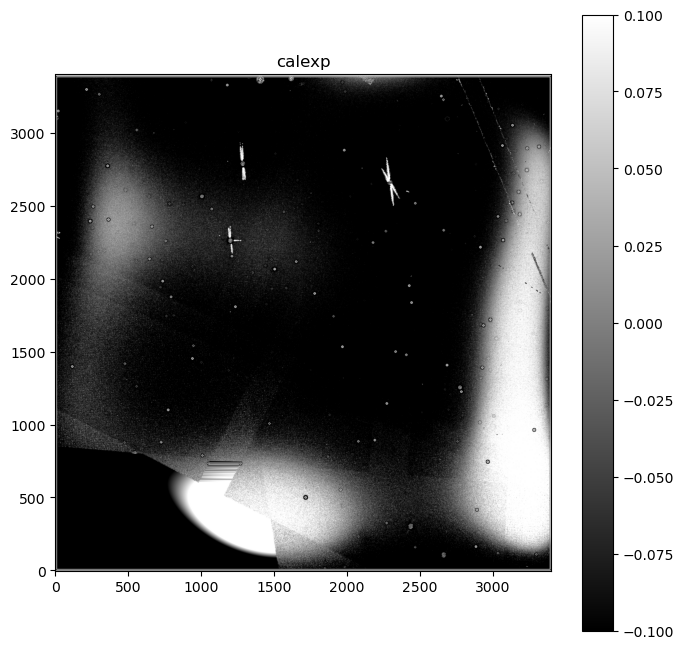

In [35]:
diff = gems.diff_AlardLupton(coadd, inj_coadd, warp=True)

plt.figure(figsize=(8,8))
plt.imshow(diff.image.array, origin="lower", cmap="gray",
           vmin=np.percentile(diff.image.array, 1),
           vmax=np.percentile(diff.image.array, 99))
plt.colorbar()
plt.title("calexp")
plt.show()

### Testing the coadd with the rotate/inject visits

In [39]:
info_cc = coadd.getInfo()
info_ic = inj_coadd.getInfo()
inputs_cc = info_cc.getCoaddInputs()
inputs_ic = info_ic.getCoaddInputs()

In [40]:
inputs_cc.visits.asAstropy()

id,bbox_min_x,bbox_min_y,bbox_max_x,bbox_max_y,goodpix,weight,filter
,pix,pix,pix,pix,,,
int64,int32,int32,int32,int32,int32,float64,str32
2024111700345,8544,-456,12455,3455,1315761,0.0008240437947005582,i_06
2024111700348,8544,-456,12455,3455,2861887,0.0007979855514706616,i_06
2024111700349,8544,-456,12455,3455,5763028,0.0008006550666899183,i_06
2024111700360,8544,-456,12455,3455,1293335,0.0007985024482641637,i_06
2024111700362,8544,-456,12455,3455,387785,0.0008299154155645411,i_06
2024111700363,8544,-456,12455,3455,7339722,0.0008201286243347281,i_06
2024111800088,8544,-456,12455,3455,1383555,0.0015079465664190285,i_06
2024111800090,8544,-456,12455,3455,5686214,0.0015368412212227107,i_06


In [41]:
inputs_ic.visits.asAstropy()

id,bbox_min_x,bbox_min_y,bbox_max_x,bbox_max_y,goodpix,weight,filter
,pix,pix,pix,pix,,,
int64,int32,int32,int32,int32,int32,float64,str32
2024111700345,8544,-456,12455,3455,1315761,0.0008240437947004057,i_06
2024111700348,8544,-456,12455,3455,2861887,0.0007979855514707475,i_06
2024111700349,8544,-456,12455,3455,5763028,0.0008006550666896956,i_06
2024111700360,8544,-456,12455,3455,1293335,0.0007985024482625164,i_06
2024111700362,8544,-456,12455,3455,387785,0.0008299154155687362,i_06
2024111700363,8544,-456,12455,3455,7339722,0.000820128624334273,i_06
2024111800088,8544,-456,12455,3455,1383555,0.0015079465664124471,i_06
2024111800090,8544,-456,12455,3455,5686214,0.0015368412212213814,i_06
